# Simulate population with spontaneus creation

There are many things in nature that spontaneusly assemble into specific things, for example raindrops.

Raindrops are assmebled for a period of time bookended by assembly and dissassembly, let's call these birth, life, and death for convenience. 

The purpose of this notebook is to simulate and model this phenomena mathematically to better understand it's physical properties.

In [ ]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random


## Build the Simulation

Each raindrop is represented by the `entity` object, which has just one property, `period`, to keep track of how many time steps the `entity` (randrop) has survived in the current simulation.

The `environment` class defines the parameters of the environment, which in this simple simulation are just `birth_rate` and `death_chance`. The `environment` class also keeps track of the current population of entities, or raindrops 'alive'. When an instance of the `environment` is called, it represents one time step. At each time step, every `entity` currently 'alive' has a chance of 'dying' based on the `death_chance`, and any new `entity` 'born' based on the `birth_rate` is added to the `population` list. `population` represents the current population, while `history` tracks the size of the population through each time step of the simulation.




In [270]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""
    
    f = Fraction(chance).limit_denominator()
    chance = random.randint(1, f.denominator)
    return chance <= f.numerator


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history =[]

    def __call__(self):
        self.population = [e() for e in self.population if not trial(self.death_chance)]
        self.population.append(entity())
        self.history.append(len(self.population))

## Run the Simulation


In [271]:
#Create an instance of environment with chosen parameters
env = environment(1, .1)

In [383]:
# Press CTRL-ENTER to bring the simulation forward by one time step.
env()
env.population

[14, 13, 11, 4, 3, 2, 1, 0]

## Visualize the Simulation's Outcome

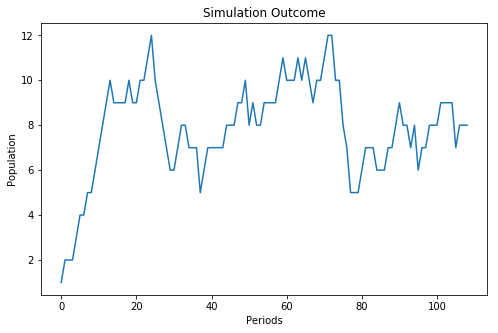

In [384]:
fig = plt.figure(figsize=(8,5))
ax = plt.axes()
ax.set_title("Simulation Outcome")
ax.xaxis.set_label_text("Periods")
ax.yaxis.set_label_text("Population")

ax.plot(env.history)
plt.show()